In [1]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]
    turn: int

def node_human_input(state: ChatState) -> dict:
    new_msg = HumanMessage(content="What is the capital of france?")
    print(f" [human_input] appending: {new_msg.content}")
    return {
        "messages": [new_msg],
        "turn": state["turn"] + 1
    }

def node_ai_reply(state: ChatState) -> dict:
    new_msg = HumanMessage(content="The capital of France is Paris")
    print(f" [ai_reply] appending: {new_msg.content}")
    return {
            "messages": [new_msg]
        }

builder = StateGraph(ChatState)

builder.add_node("human_input", node_human_input)
builder.add_node("ai_reply", node_ai_reply)

builder.add_edge(START, "human_input")
builder.add_edge("human_input", "ai_reply")
builder.add_edge("ai_reply", END)

graph = builder.compile()

result = graph.invoke({"messages": [], "turn": 0})

print(f"final result::: ", result)

 [human_input] appending: What is the capital of france?
 [ai_reply] appending: The capital of France is Paris
final result:::  {'messages': [HumanMessage(content='What is the capital of france?', additional_kwargs={}, response_metadata={}, id='43b20827-9c95-4001-b734-03a829e23f5b'), HumanMessage(content='The capital of France is Paris', additional_kwargs={}, response_metadata={}, id='9cdec5aa-bedd-42ec-b2e6-5b5cfaec3a82')], 'turn': 1}


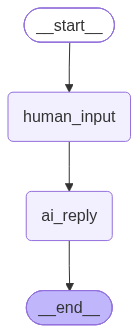

In [2]:
from IPython.display import Image, display

graph = builder.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)